In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
import pandas_datareader.data as web
import datetime
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns


start_date = datetime.datetime(2015, 1, 1)
end_date = datetime.datetime(2025, 12, 31)

ff_global_dict = web.DataReader('F-F_Research_Data_Factors_daily', 'famafrench', start=start_date, end=end_date)
ff_global = ff_global_dict[0] / 100.0   #Fama-French library can be unavailable sometimes

ff_mom_dict = web.DataReader('F-F_Momentum_Factor_daily', 'famafrench', start=start_date, end=end_date)
mom = ff_mom_dict[0] / 100.0
mom.columns = ['WML']

ff_global_4f = pd.merge(ff_global, mom, left_index=True, right_index=True)

/tmp/ipykernel_1527/475957602.py:11: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_global_dict = web.DataReader('F-F_Research_Data_Factors_daily', 'famafrench', start=start_date, end=end_date)
/tmp/ipykernel_1527/475957602.py:14: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_mom_dict = web.DataReader('F-F_Momentum_Factor_daily', 'famafrench', start=start_date, end=end_date)


In [4]:
# MSCI components can be viewed publically at https://www-cdn.msci.com/web/msci/index-tools/constituents

file_path = '/content/drive/MyDrive/Week4/MSCI_world_CIK.xlsx'
df = pd.read_excel(file_path)

Successfully loaded


In [5]:
all_tickers = ['MCHI'] + df['Ticker'].tolist()
price_data = yf.download(all_tickers, start='2015-01-01', end='2025-12-31', interval='1d', auto_adjust=False)['Close']
price_data_cleaned = price_data.dropna(axis=1, how='all')

[*********************100%***********************]  982 of 982 completed
ERROR:yfinance:
28 Failed downloads:
ERROR:yfinance:['EMAT', 'MSSHY', 'TMTNY', 'BLMOY', 'TRMOY', 'SYNSY']: YFPricesMissingError('possibly delisted; no price data found  (1d 2015-01-01 -> 2025-12-31) (Yahoo error = "Data doesn\'t exist for startDate = 1420088400, endDate = 1767157200")')
ERROR:yfinance:['SAND', 'ADDTF', 'K', 'NTCS', 'RCWBY', 'ZSHLY', 'OXYWS', 'SCSXY', 'SSHBY', 'THCLY', 'URW.AS', 'ATHNY', 'SVICY', 'YGSHY', 'SAPUY', 'FHFFY', 'CONE', 'MROSY', 'HCIC', 'SCRNY', 'MSTKY']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:['1COV.DE']: YFPricesMissingError('possibly delisted; no price data found  (1d 2015-01-01 -> 2025-12-31)')


In [8]:
# compute stock price returns and merge with F-F factor time series
returns_data = price_data_cleaned.pct_change(fill_method=None)
returns_data.index = returns_data.index.tz_localize(None)

merged_df = pd.merge(returns_data, ff_global_4f, left_index=True, right_index=True, how='inner')

ff_factors_cols = ['Mkt-RF', 'SMB', 'HML', 'WML', 'RF_y']
merged_df.dropna(subset=ff_factors_cols, inplace=True)

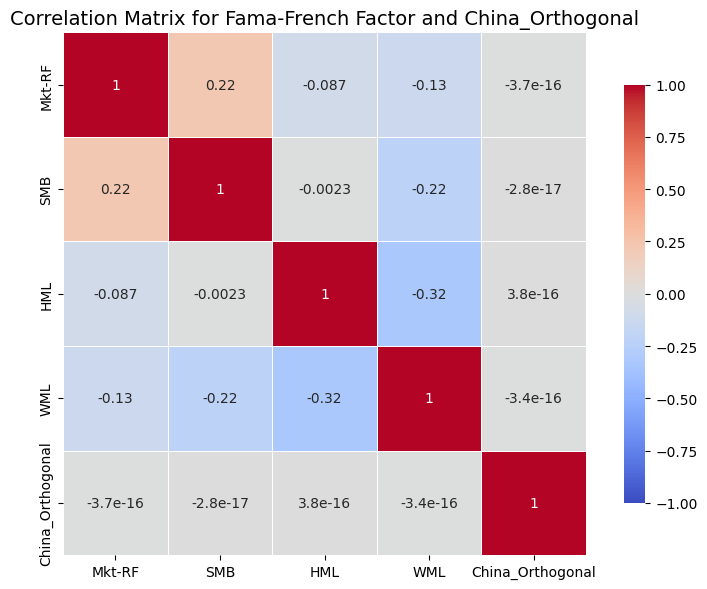

In [21]:
# Define the 5 factors we want to analyze
factor_cols = ['Mkt-RF', 'SMB', 'HML', 'WML', 'China_Orthogonal']

# Calculate the correlation matrix
corr_matrix = merged_df[factor_cols].corr()

# Set up the matplotlib figure
plt.figure(figsize=(8, 6))

# Draw the heatmap with seaborn
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Correlation Matrix for Fama-French Factor and China_Orthogonal', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
# calculate excess returns
stock_cols = [col for col in merged_df.columns if col not in ff_factors_cols]
excess_returns_df = merged_df[stock_cols].sub(merged_df['RF_y'], axis=0)
excess_returns_df.columns = [f'{col}_Excess' for col in stock_cols]
merged_df = pd.concat([merged_df, excess_returns_df], axis=1)

In [10]:
# clean dataframe to handle NaN entries
china_subset = merged_df[['MCHI', 'Mkt-RF', 'SMB', 'HML', 'WML']].dropna()

# OLS regression and residualize China factor
Y_china_raw = china_subset['MCHI']
X_baseline = china_subset[['Mkt-RF', 'SMB', 'HML', 'WML']]
X_baseline_with_intercept = sm.add_constant(X_baseline)
orthogonalization_model = sm.OLS(Y_china_raw, X_baseline_with_intercept).fit()
merged_df['China_Orthogonal'] = orthogonalization_model.resid

In [14]:
# regression with the extended model including china factor
def factor_regression_china(ticker, data):
    required_cols = [ticker, 'Mkt-RF', 'SMB', 'HML', 'WML', 'China_Orthogonal', 'RF_y']
    subset_df = data[required_cols].copy()

    subset_df['Excess_Return'] = subset_df[ticker] - subset_df['RF_y']

    clean_df = subset_df.dropna(subset=['Excess_Return', 'Mkt-RF', 'SMB', 'HML', 'WML', 'China_Orthogonal'])

    Y = clean_df['Excess_Return']
    X = clean_df[['Mkt-RF', 'SMB', 'HML', 'WML', 'China_Orthogonal']]
    X_with_intercept = sm.add_constant(X)

    model = sm.OLS(Y, X_with_intercept).fit()

    coef = model.params['China_Orthogonal']
    std_err = model.bse['China_Orthogonal']
    p_value = model.pvalues['China_Orthogonal']
    r_squared = model.rsquared
    aic = model.aic

    return model, coef, std_err, p_value, r_squared, aic


In [15]:
# regression with Carlhart model without China factor
def factor_regression_base(ticker, data):
    required_cols = [ticker, 'Mkt-RF', 'SMB', 'HML', 'WML', 'RF_y']
    subset_df = data[required_cols].copy()

    subset_df['Excess_Return'] = subset_df[ticker] - subset_df['RF_y']

    clean_df = subset_df.dropna(subset=['Excess_Return', 'Mkt-RF', 'SMB', 'HML', 'WML', ])

    Y = clean_df['Excess_Return']
    X = clean_df[['Mkt-RF', 'SMB', 'HML', 'WML']]
    X_with_intercept = sm.add_constant(X)

    model = sm.OLS(Y, X_with_intercept).fit()

    r_squared = model.rsquared
    aic = model.aic

    return model, r_squared, aic


In [18]:
results = []

target_tickers = [col for col in stock_cols if col not in ['MCHI', 'China_Orthogonal']]

for ticker in tqdm(target_tickers, desc="regressions progress"):
    try:
        model_china, coef, std_err, p_val, r_squared_china, aic_china = factor_regression_china(ticker, merged_df)
        model_base, r_squared_base, aic_base = factor_regression_base(ticker, merged_df)

        results.append({
            'ticker': ticker,
            'china_coef': coef,
            'std_err': std_err,
            'p_value': p_val,
            'R_Squared_china': r_squared_china,
            'R_Squared_base': r_squared_base,
            'R_Squared_improve' : r_squared_china - r_squared_base,
            'AIC_china': aic_china,
            'AIC_base': aic_base,
            'AIC_improve': aic_base - aic_china  # Positive is better model (lower AIC)
        })
    except Exception as e:
        pass

df_exposure = pd.DataFrame(results)

df_exposure = df_exposure.drop_duplicates(subset=['ticker']).reset_index(drop=True)
df_exposure = df_exposure.sort_values(by='p_value', ascending=True).reset_index(drop=True)


Running Regressions:   0%|          | 0/1907 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/tmp/ipykernel_1527/1035739542.py:20: RuntimeWarning: invalid value encountered in scalar subtract
  'R_Squared_improve' : r_squared_china - r_squared_base,


In [27]:
def get_info(ticker):
    try:
        info = yf.Ticker(ticker).info
        return pd.Series([info.get('country', 'Unknown'), info.get('industry', 'Unknown'), info.get('sector', 'N/A')])
    except:
        return pd.Series(['Unknown', 'Unknown'])
tqdm.pandas(desc="fetch progress")

country_to_region = {
    'United States': 'North America',
    'Canada': 'North America',
    'Netherlands': 'Europe',
    'Japan': 'Asia',
    'Germany': 'Europe',
    'United Kingdom': 'Europe',
    'France': 'Europe',
    'Switzerland': 'Europe',
    'Belgium': 'Europe',
    'Ireland': 'Europe',
    'Italy': 'Europe',
    'Portugal': 'Europe',
    'Spain': 'Europe',
    'Luxembourg': 'Europe',
    'Australia': 'Oceania',
    'Singapore': 'Asia',
    'Chile': 'South America',
    'Uruguay': 'South America',
    'Norway': 'Europe',
    'Israel': 'Asia',
    'Hong Kong': 'Asia',
    'Taiwan': 'Asia',
    'South Korea': 'Asia',
    'Mexico': 'North America',
    'Brazil': 'South America',
    'India': 'Asia',
    'China': 'Asia',
    'N/A': 'Unknown'
}
df_exposure[['country', 'industry', 'sector']] = df_exposure['ticker'].progress_apply(get_info)
df_exposure['region'] = df_exposure['country'].map(country_to_region).fillna('Unknown')

# t-statistic > 3 is equivalent to p-value < 0.0027
# MSCI China is highly correlated with large cap stocks in China and Hong Kong
df_exposure_pval = df_exposure[(df_exposure["p_value"] < 0.0027) & ((df_exposure["country"] != "China") & (df_exposure["country"] != "Hong Kong")) ]

fetch progress:   0%|          | 0/952 [00:00<?, ?it/s]

ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: RF_X"}}}


In [31]:
# filter for names where coefficient for China factor is statistically significant and China factor improves model fit
(df_exposure_pval[(df_exposure_pval["R_Squared_improve"] > 0.01) & (df_exposure_pval["AIC_improve"] > 10)][["ticker", "china_coef", "p_value", "R_Squared_improve", "AIC_improve", "country", "industry"]].sort_values(by="AIC_improve", ascending=False))["ticker"].values

array(['BHP', 'SCCO', 'LVS', 'HSBC', 'MT', 'TECK', 'FCX', 'BMWKY', 'TTE',
       'IFNNY', 'EQNR', 'CHT', 'WDS', 'BP', 'ING', 'SAN', 'E', 'MBGAF',
       'STLA', 'SONY', 'MGA', 'VIV', 'STM', 'BBVA', 'SHEL', 'PHG',
       'YARIY', 'BUD', 'JOF', 'TS', 'ASML', 'POAHF', 'ASX', 'HMC', 'MU',
       'IX', 'RSG', 'GRAB', 'MELI', 'NMR', 'EL', 'TM', 'ENIC', 'CMBT',
       'PPRUF', 'EDPFY', 'RIVN', 'IE'], dtype=object)

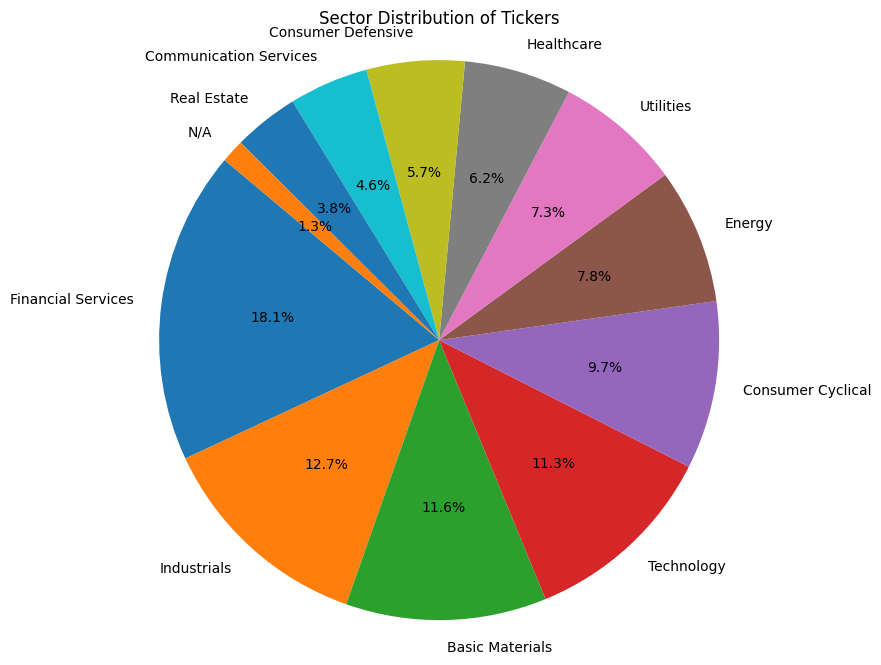

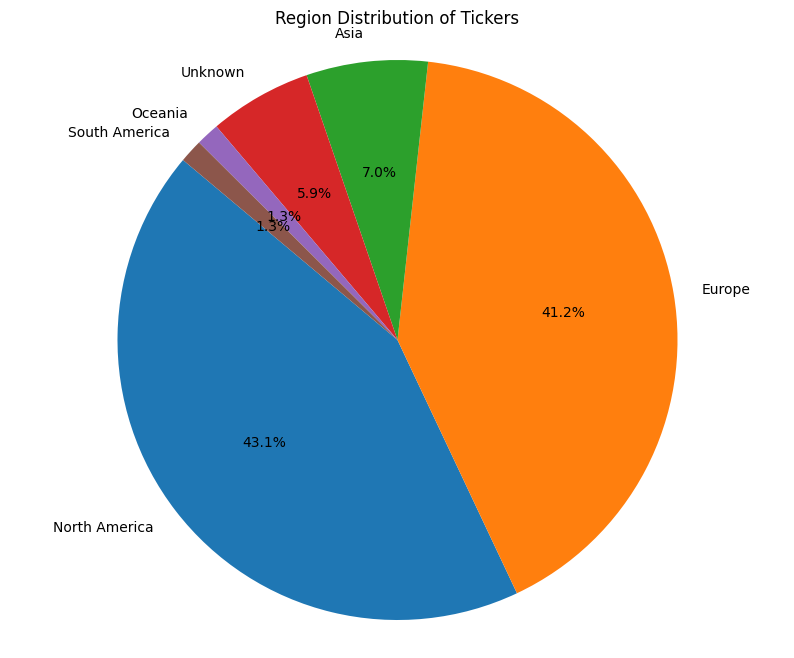

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

# Use the existing dataframe containing the significant p-value results
df_data = df_exposure_pval.copy()

# --- Pie Chart for Sector Distribution ---
sector_counts = df_data['sector'].value_counts()

plt.figure(figsize=(10, 8))
plt.pie(sector_counts, labels=sector_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Sector Distribution of Tickers')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# --- Pie Chart for Region Distribution ---
region_counts = df_data['region'].value_counts()

plt.figure(figsize=(10, 8))
plt.pie(region_counts, labels=region_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Region Distribution of Tickers')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()
